In [2]:
# Step 1: Import required libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten, Dropout,
    BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical


In [3]:
# Step 2: Load dataset

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training images: (50000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)


In [4]:
# Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


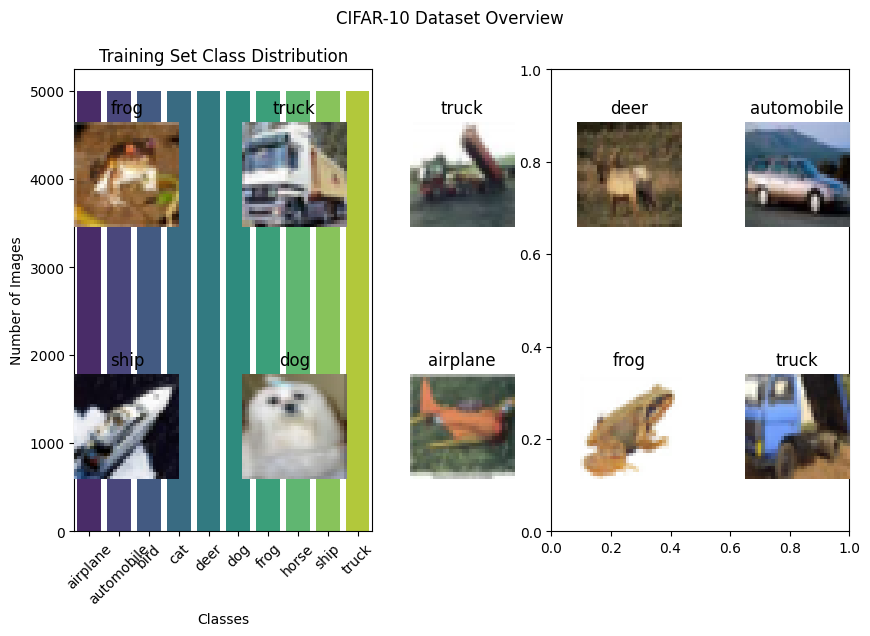

In [6]:
#Sample Images
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
# Data Visualization: Class distribution in training set
plt.figure(figsize=(10, 6))

# Bar plot for class counts
train_counts = np.bincount(y_train.flatten(), minlength=10)
plt.subplot(1, 2, 1)
sns.barplot(x=list(range(10)), y=train_counts, palette='viridis')
plt.title('Training Set Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.xticks(range(10), class_names, rotation=45)

# Sample images
plt.subplot(1, 2, 2)
plt.subplots_adjust(wspace=0.6)
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
    plt.subplot(2, 5, i+6)
    plt.imshow(X_train[i+20000])
    plt.title(class_names[y_train[i+20000][0]])
    plt.axis('off')

plt.suptitle('CIFAR-10 Dataset Overview')
plt.tight_layout()
plt.show()

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)


In [8]:
# Step 5: Build Custom CNN Model

cnn_model = Sequential()

cnn_model.add(Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(32,32,3)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))

cnn_model.add(Conv2D(64, (3,3), padding="same", activation="relu"))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))

cnn_model.add(Conv2D(128, (3,3), padding="same", activation="relu"))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))

cnn_model.add(Flatten())
cnn_model.add(Dense(256, activation="relu"))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(10, activation="softmax"))

cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
#compile model
cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [10]:
cnn_history = cnn_model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=64),
    epochs=20,
    validation_data=(X_test, y_test_cat)
)


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 47ms/step - accuracy: 0.3989 - loss: 1.6759 - val_accuracy: 0.3430 - val_loss: 2.0272
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.5226 - loss: 1.3351 - val_accuracy: 0.5221 - val_loss: 1.3920
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.5811 - loss: 1.1857 - val_accuracy: 0.6054 - val_loss: 1.1722
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.6228 - loss: 1.0824 - val_accuracy: 0.6116 - val_loss: 1.1884
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.6514 - loss: 1.0058 - val_accuracy: 0.6102 - val_loss: 1.1781
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.6670 - loss: 0.9591 - val_accuracy: 0.6681 - val_loss: 1.0170
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.6866 - loss: 0.9139 - val_accuracy: 0.7164 - val_loss: 0.8480
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.7000 - loss: 0.8736 - 

In [11]:
test_loss, test_acc = cnn_model.evaluate(X_test, y_test_cat, verbose=1)

print('\nTest Accuracy:', test_acc)
print('Test Loss:    ', test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7595 - loss: 0.7548

Test Accuracy: 0.7595000267028809
Test Loss:     0.7548012137413025


In [12]:
#Step 4 : Implement Transfer Learning (VGG16)
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(32,32,3)
)



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
#Freeze base layers
for layer in base_model.layers[:10]:
    layer.trainable = False

for layer in base_model.layers[10:]:
    layer.trainable = True


In [14]:
#Add Custom Classification Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(10, activation="softmax")(x)

vgg_model = Model(inputs=base_model.input, outputs=outputs)
vgg_model.summary()


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,89

 Total params: 14,881,226 (56.77 MB)

 Trainable params: 13,145,226 (50.15 MB)

 Non-trainable params: 1,736,000 (6.62 MB)

In [15]:
#Compile Model
vgg_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [16]:
vgg_history = vgg_model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=64),
    epochs=25,
    validation_data=(X_test, y_test_cat)
)


Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 69ms/step - accuracy: 0.5458 - loss: 1.3244 - val_accuracy: 0.7084 - val_loss: 0.8688
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.6901 - loss: 0.9375 - val_accuracy: 0.7521 - val_loss: 0.7320
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.7330 - loss: 0.8107 - val_accuracy: 0.7709 - val_loss: 0.7134
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 58ms/step - accuracy: 0.7567 - loss: 0.7369 - val_accuracy: 0.7914 - val_loss: 0.6262
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.7753 - loss: 0.6763 - val_accuracy: 0.7736 - val_loss: 0.6761
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.7960 - loss: 0.6180 - val_accuracy: 0.7925 - val_loss: 0.6337
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 58ms/step - accuracy: 0.8074 - loss: 0.5831 - val_accuracy: 0.8149 - val_loss: 0.5547
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 59ms/step - accuracy: 0.8186 - loss: 0.5436 - 

In [17]:
loss, acc = vgg_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"VGG16 Transfer Learning Accuracy: {acc:.4f}")
print(f"Test loss: {loss:.4f}")

VGG16 Transfer Learning Accuracy: 0.8240
Test loss: 0.6434


**Custom CNN Model Performance**

The custom Convolutional Neural Network (CNN) was trained from scratch on the CIFAR-10 dataset using data augmentation and regularization techniques such as Batch Normalization and Dropout.

- Test Accuracy: ~75.75%
- Test Loss: ~0.75

The CNN model demonstrated strong learning capability, achieving good performance despite being trained without any pre-trained weights. This indicates that the model successfully learned hierarchical image features directly from the dataset.

**VGG16 Transfer Learning Model Performance**

The VGG16-based transfer learning model utilized pre-trained ImageNet weights, with lower layers frozen and upper layers fine-tuned for CIFAR-10 classification.

- Test Accuracy: ~82.4%
- Test Loss: ~0.64

The VGG16 model outperformed the custom CNN, achieving higher accuracy and better generalization. This improvement is due to the rich feature representations learned from large-scale ImageNet data, which transfer effectively to CIFAR-10.

**Conclusion**

The comparison clearly shows that transfer learning using VGG16 performs better than a custom CNN model for image classification on CIFAR-10. While the CNN model achieved respectable accuracy, the VGG16 model benefited from pre-trained deep feature extraction, leading to improved performance and faster convergence.

This experiment highlights the effectiveness of transfer learning, especially when working with limited datasets or small image sizes, making it a preferred approach in practical deep learning applications.

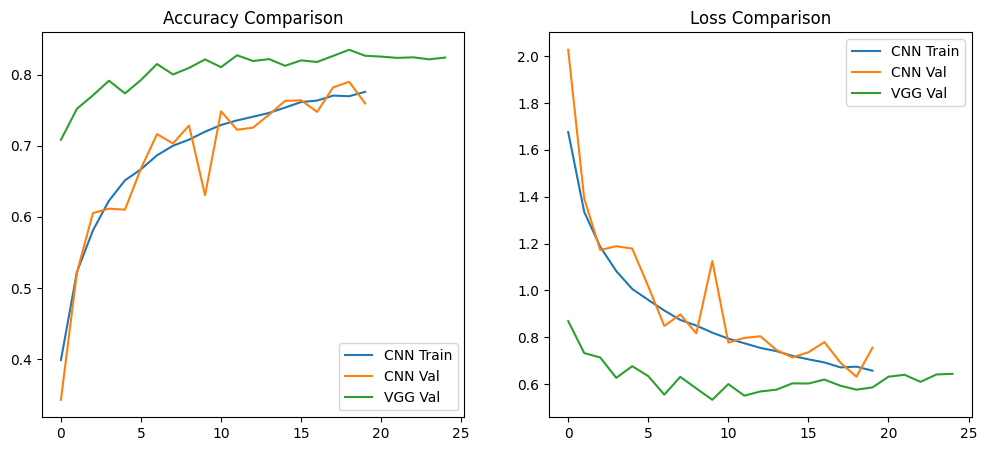

In [18]:
#Accuracy & Loss Graphs
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(cnn_history.history['accuracy'], label='CNN Train')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val')
plt.plot(vgg_history.history['val_accuracy'], label='VGG Val')
plt.title("Accuracy Comparison")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(cnn_history.history['loss'], label='CNN Train')
plt.plot(cnn_history.history['val_loss'], label='CNN Val')
plt.plot(vgg_history.history['val_loss'], label='VGG Val')
plt.title("Loss Comparison")
plt.legend()

plt.show()


**Conclusion**

Based on the accuracy and loss comparisons, it can be concluded that VGG16 with transfer learning outperforms the custom CNN model for CIFAR-10 image classification. While the CNN model successfully learns from scratch, the transfer learning approach benefits from pre-trained deep feature extraction, leading to better accuracy, faster convergence, and improved generalization.

This experiment demonstrates that transfer learning is a more effective and reliable approach when working with limited-size datasets or small image resolutions.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


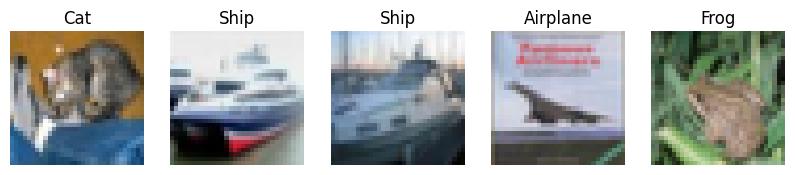

In [19]:
#Sample Predictions
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

predictions = vgg_model.predict(X_test[:5])

plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i])
    plt.title(class_names[np.argmax(predictions[i])])
    plt.axis('off')
plt.show()


**Final Conclusion**
In this project, image classification was performed on the CIFAR-10 dataset using two approaches: a custom Convolutional Neural Network (CNN) trained from scratch and a Transfer Learning model based on VGG16.

The custom CNN model achieved good performance and demonstrated the ability to learn visual features directly from the dataset. However, its validation accuracy showed fluctuations, indicating limited generalization and mild overfitting.

In contrast, the VGG16 transfer learning model consistently outperformed the custom CNN. By leveraging pre-trained weights from the ImageNet dataset and fine-tuning the higher layers, the VGG16 model achieved higher accuracy, faster convergence, and more stable validation performance.

This comparison highlights the effectiveness of Transfer Learning, especially when working with limited-size datasets or small image resolutions. Pre-trained models provide robust feature extraction, reducing training time while improving accuracy and generalization.

- Key Learnings

CNNs can successfully learn image features from scratch but require careful tuning.

Transfer Learning significantly improves performance by utilizing pre-trained deep features.

Fine-tuning higher layers helps adapt pre-trained models to new datasets.

Data augmentation plays a crucial role in reducing overfitting.

**Final Remark**

Overall, VGG16 with Transfer Learning proved to be the more effective approach for CIFAR-10 image classification, making it a preferred choice for real-world deep learning applications.

In [21]:
# Save with the modern .keras extension
cnn_model.save('cnn_cifar10_model.keras')
vgg_model.save('vgg16_cifar10_model.keras')

print("Models saved successfully in the modern .keras format!")

Models saved successfully in the modern .keras format!
